## CECS 381 - Programming Assignment 2

**Name:** Carlos Aguilera

**Student ID:** 032455616

**Due:** August 13, 2026


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# use fixed seed for reproducibility
random.seed(42)
np.random.seed(42)

## Problem 1: Use random sampling to estimate a constant and an integral, and study the error rate.

### 1(a) - Estimate pi with the dart method

Sample points in the unit square and count the fraction with x^2 + y^2 <= 1. Report estimates for n = 10^2, 10^4, 10^6.

In [2]:
def estimate_pi(n):
    """
    Throw n random darts at the unit square and return an estimate of pi.

    The quarter circle takes up pi/4 of the square, so the fraction that
    lands inside times 4 gives us pi.
    """
    x = np.random.random(n)
    y = np.random.random(n)

    inside = np.sum(x**2 + y**2 <= 1)

    return 4 * inside / n

In [3]:
for n in [10**2, 10**4, 10**6]:
    print(n, estimate_pi(n))

print()
print("true pi:", np.pi)

100 3.2
10000 3.16
1000000 3.142056

true pi: 3.141592653589793


### 1(b) - Estimate the integral of e^(-x^2) from 0 to 1

Compare with the true value of about 0.7468.

In [4]:
def estimate_integral(n):
    """
    Estimate the integral of e^(-x^2) from 0 to 1 using n random samples.

    The interval has width 1, so the average of the function at random
    points in [0, 1] is the integral.
    """
    x = np.random.random(n)

    return np.mean(np.exp(-x**2))

In [5]:
estimate = estimate_integral(10**6)

print("estimate:", estimate)
print("true value:", 0.7468)
print("error:", abs(estimate - 0.7468))

estimate: 0.7466706952551044
true value: 0.7468
error: 0.0001293047448955864


### 1(c) - Error versus n on log-log axes

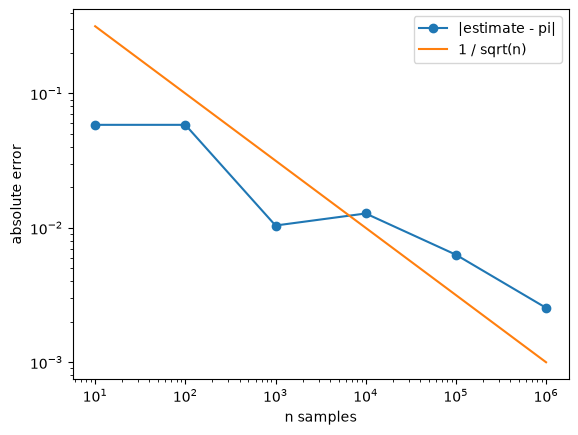

In [6]:
ns = [10**k for k in range(1, 7)]
errors = [abs(estimate_pi(n) - np.pi) for n in ns]
reference = [1 / np.sqrt(n) for n in ns]

plt.loglog(ns, errors, marker='o', label='|estimate - pi|')
plt.loglog(ns, reference, label='1 / sqrt(n)')
plt.xlabel('n samples')
plt.ylabel('absolute error')
plt.legend()
plt.show()

### Comment on the observed convergence rate

In the graph of log-log type, the error line decreases with an approximate slope similar to the 1/sqrt(n) line, whose slope is -1/2. In other words, the error decreases in proportion to 1/sqrt(n), which is how the Monte Carlo method should work.

However, there is an important disadvantage of this procedure, namely, its very slow decrease. In order to reduce the error by 10 times, we need 100 times more sampling. It is because of this reason that at n=10^2, our estimation can be off in the first digit, whereas at n=10^6 the accuracy of estimation reaches 3 digits only.

## Problem 2: Markov chain simulation and the stationary distribution

The server chain has states Up (0) and Down (1) with transition matrix P = [[0.8, 0.2], [0.6, 0.4]].

### 2(a) - Simulate the chain

Simulate T = 10^6 steps starting from Up, recording the fraction of time spent in each state.

In [7]:
P = np.array([[0.8, 0.2],
              [0.6, 0.4]])


def simulate_chain(P, T):
    """
    Walk the chain for T steps starting from Up (state 0) and return
    the fraction of time spent in each state.
    """
    state = 0
    counts = [0, 0]

    for _ in range(T):
        counts[state] += 1

        # row `state` of P gives the chances of where we go next
        if random.random() < P[state][0]:
            state = 0
        else:
            state = 1

    return [c / T for c in counts]

In [8]:
fractions = simulate_chain(P, 10**6)

print("fraction of time Up:", fractions[0])
print("fraction of time Down:", fractions[1])

fraction of time Up: 0.750511
fraction of time Down: 0.249489


### 2(b) - Stationary distribution by power iteration

Repeat pi <- pi P until it stops changing, then confirm it matches the empirical fractions.

In [9]:
def power_iteration(P, steps=1000):
    """
    Start from a uniform guess and keep multiplying by P until the
    vector stops changing.
    """
    pi = np.array([0.5, 0.5])

    for _ in range(steps):
        new_pi = pi @ P
        change = np.max(np.abs(new_pi - pi))
        pi = new_pi

        if change < 1e-12:
            break

    return pi

In [10]:
pi_power = power_iteration(P)

print("power iteration:", pi_power)
print("simulation:     ", fractions)

power iteration: [0.75 0.25]
simulation:      [0.750511, 0.249489]


### 2(c) - Stationary distribution as a left eigenvector


In [11]:
def stationary_eigenvector(P):
    """
    The stationary distribution is the left eigenvector of P with
    eigenvalue 1, which is the same as the right eigenvector of P transposed.
    """
    values, vectors = np.linalg.eig(P.T)

    # pick the eigenvector whose eigenvalue is closest to 1
    i = np.argmin(np.abs(values - 1))
    vec = np.real(vectors[:, i])

    # scale it so the probabilities add up to 1
    return vec / np.sum(vec)

In [12]:
pi_eigen = stationary_eigenvector(P)

print("simulation:     ", fractions)
print("power iteration:", pi_power)
print("eigenvector:    ", pi_eigen)

simulation:      [0.750511, 0.249489]
power iteration: [0.75 0.25]
eigenvector:     [0.75 0.25]


## Problem 3: PageRank by power iteration

The 4-page web from Class 20: A links to B and D; B links to C; C links to A and B; D links to C.

### 3(a) - Build the link matrix H and the Google matrix G

G = alpha * H + (1 - alpha) * (1/N) with alpha = 0.85.

In [13]:
pages = ['A', 'B', 'C', 'D']

# H[i][j] = chance of following a link from page i to page j, so rows sum to 1
H = np.array([
    [0.0, 0.5, 0.0, 0.5],   # A links to B and D
    [0.0, 0.0, 1.0, 0.0],   # B links to C
    [0.5, 0.5, 0.0, 0.0],   # C links to A and B
    [0.0, 0.0, 1.0, 0.0],   # D links to C
])

alpha = 0.85
N = len(pages)

G = alpha * H + (1 - alpha) * np.ones((N, N)) / N

print("rows of H sum to:", H.sum(axis=1))
print()
print(G)

rows of H sum to: [1. 1. 1. 1.]

[[0.0375 0.4625 0.0375 0.4625]
 [0.0375 0.0375 0.8875 0.0375]
 [0.4625 0.4625 0.0375 0.0375]
 [0.0375 0.0375 0.8875 0.0375]]


### 3(b) - Power iteration from the uniform vector

In [14]:
def pagerank(G, steps=1000):
    """
    Start every page with an equal share and keep multiplying by G
    until the ranks stop changing.
    """
    rank = np.ones(len(G)) / len(G)

    for _ in range(steps):
        new_rank = rank @ G
        change = np.max(np.abs(new_rank - rank))
        rank = new_rank

        if change < 1e-12:
            break

    return rank

In [15]:
ranks = pagerank(G)

for page, r in zip(pages, ranks):
    print(page, r)

print()
print("sums to:", ranks.sum())

A 0.20195025438085343
B 0.28777911249311416
C 0.38694177501377264
D 0.12332885811226078

sums to: 1.0000000000000009


### 3(c) - Report the ranking

In [16]:
order = np.argsort(ranks)[::-1]

for place, i in enumerate(order, start=1):
    print(place, pages[i], ranks[i])

1 C 0.38694177501377264
2 B 0.28777911249311416
3 A 0.20195025438085343
4 D 0.12332885811226078


### Which page wins, and why? Does link quality or quantity explain the result?

C wins the competition, and the final ranking is C, B, A, and D.

Link count cannot explain this ranking. Both C and B have two incoming links each; however, C has a higher ranking because its links are stronger. All the rank of B and D flows to C, whereas the links to B are shared between many pages.

C gains additional value from the full link that B gives to C. C–B cycle increases the ranking of C even more because B transfers all of its rank to C, while C transfers only half of its rank to B.

D is ranked last because it receives only one incoming link from A that is ranked quite low.